# Redes Neurais Artificiais

**Francisco Aparecido Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Nesta aula, vamos estudar redes neurais artificiais usando exclusivamente o **scikit-learn**. Vamos começar pelo modelo mais simples (o Perceptron), entender por que ele é limitado, e então evoluir para o **Multilayer Perceptron (MLP)**, que resolve essa limitação empilhando camadas de neurônios. Vamos aplicar os dois modelos em dados reais, tanto para **classificação** quanto para **regressão**, e usar `GridSearchCV` para ajustar os hiperparâmetros da rede.

Uma rede neural artificial é, em essência, uma função matemática composta por unidades simples (os **neurônios artificiais**) organizadas em camadas, inspirada — apenas de forma bem abstrata — no funcionamento de neurônios biológicos: cada neurônio recebe sinais de entrada, os combina, e produz um sinal de saída que é passado adiante.

O que torna as redes neurais poderosas não é a complexidade de cada neurônio individual (que é bem simples, como veremos), mas a capacidade de **compor muitos neurônios simples em camadas** para representar funções bastante complexas — inclusive relações altamente não lineares entre os atributos e o alvo, que modelos lineares (como a regressão logística "pura", sem atributos derivados) não conseguem capturar.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn import metrics

np.random.seed(10)

## Perceptron

O **Perceptron**, proposto por Frank Rosenblatt em 1958, é o modelo mais simples de neurônio artificial e a base histórica das redes neurais. Ele é um classificador **linear**: recebe um vetor de atributos $\mathbf{x}=(x_1,\ldots,x_p)$, calcula uma combinação linear ponderada,
$$
z = w_0 + w_1x_1 + w_2x_2 + \ldots + w_px_p,
$$
e passa esse valor por uma **função de ativação em degrau** (*step function*) para decidir a classe:
$$
\hat y = \begin{cases} 1, & \text{se } z \geq 0 \\ 0, & \text{caso contrário.} \end{cases}
$$

Notem que isso é muito parecido com a regressão logística. A diferença central é a função de ativação: a regressão logística usa a sigmoide (uma transição suave entre 0 e 1, interpretável como probabilidade), enquanto o Perceptron original usa uma função em degrau (uma decisão binária abrupta, sem noção de probabilidade).

O **aprendizado** ocorre ajustando os pesos $w$ iterativamente: para cada observação de treinamento, o modelo faz uma predição e, se ela estiver errada, os pesos são corrigidos na direção que reduziria esse erro:
$$
w_j \leftarrow w_j + \eta\,(y - \hat y)\,x_j,
$$
onde $\eta$ (`eta0` no scikit-learn) é a taxa de aprendizado. Note a semelhança com a regra de atualização do gradiente descendente. O Perceptron é, historicamente, um dos primeiros algoritmos de aprendizado baseados nesse mesmo princípio de ajuste incremental dos pesos.

**A limitação fundamental:** como o Perceptron é um classificador linear, ele só consegue separar corretamente classes que sejam (aproximadamente) **linearmente separáveis**, de maneira similar ao que vimos para a regressão logística. Essa limitação foi, inclusive, historicamente importante: o livro *Perceptrons* (Minsky & Papert, 1969) mostrou que um único Perceptron não consegue sequer aprender a função lógica XOR, o que contribuiu para um período de desinteresse em redes neurais (o chamado "inverno da IA"), só superado décadas depois com o desenvolvimento de redes com **múltiplas camadas**.

Na imagem a seguir, mostramos a estrutura do Perceptron.
<img src="https://lh6.googleusercontent.com/fs9F7Oyzw8jfn7yYRS-s86XF0u086KwEvW25012xc9yLGx0iKmY2oYs19wtEUrvCSPJeLfMDBrdk_7wWkhLmL8_EwBMeSp6Sb-vt4BvA1EqN2z2QjDId3d8at3Io_y-UrOzqp9Km" width=500 />

### Classificação usand o Perceptron

Vamos ler o conjunto de dados a partir de um arquivo, e aplicar o Perceptron do scikit-learn. No caso da flor íris, que tem 3 classes, o `Perceptron` do scikit-learn lida com isso automaticamente por meio da estratégia *one-vs-rest* (treina um Perceptron binário para cada classe contra as demais, e escolhe a classe do modelo mais confiante).

In [2]:
# Lê um aquivo CSV e separa os atributos (todas as colunas, exceto a última) da variável alvo (última coluna). 
# Remove colunas de identificador ('Id'/'id'), que não são atributos preditivos.
caminho = r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv"

dados = pd.read_csv(caminho, header=0)
for col_id in ("Id", "id", "ID"):
    if col_id in dados.columns:
        dados = dados.drop(columns=[col_id])
        
y = dados.iloc[:, -1].to_numpy()
X = dados.iloc[:, :-1].to_numpy().astype(float)

p = 0.7  # fração de elementos no conjunto de treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=p, random_state=42, stratify=y)

print('Treinamento:', X_train.shape, ' Teste:', X_test.shape)

Treinamento: (105, 4)  Teste: (45, 4)


> **Observação:** redes neurais (Perceptron, MLP, e praticamente qualquer modelo baseado em gradiente descendente) são sensíveis à escala dos atributos: atributos em escalas muito diferentes distorcem a superfície de custo, tornando a otimização mais lenta e instável. Por isso, **SEMPRE** padronizamos os atributos (média 0, desvio padrão 1) antes de treinar esses modelos — ajustando o `StandardScaler` apenas com os dados de treinamento, para não vazar informação do conjunto de teste.

In [3]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
clf = Perceptron(
    max_iter=100,      # número máximo de iterações (épocas) sobre os dados de treinamento
    tol=1e-4,          # o treinamento para mais cedo se a melhora entre épocas for menor esse valor
    eta0=0.1,          # taxa de aprendizado inicial
    n_jobs=-1,         # usa todos os núcleos do processador disponíveis
    random_state=8,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print('Acurácia:', accuracy_score(y_test, y_pred))

Acurácia: 0.7333333333333333


O Perceptron se sai bem no Iris, já que (como vimos na aula sobre regressão logística) essas classes são quase linearmente separáveis nesses atributos. Vamos agora ver, de forma bem concreta, o que acontece quando isso **não** é verdade.

### O Perceptron falha em problemas não linearmente separáveis

Vamos construir deliberadamente um problema em que a fronteira real entre as classes é **circular** (as duas classes formam círculos concêntricos). Esta é uma situação impossível de separar com uma única reta, não importa como ajustemos os pesos do Perceptron.

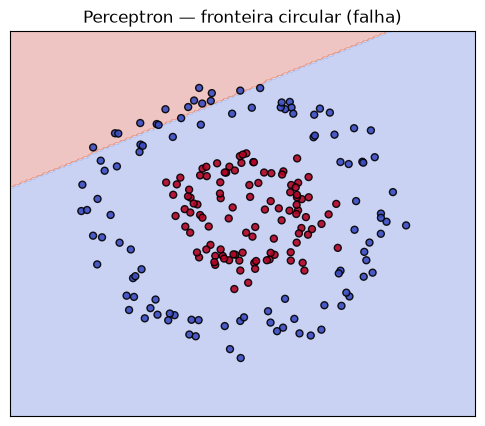

Acurácia do Perceptron nos dados circulares: 0.45555555555555555


In [5]:
from sklearn.datasets import make_circles
import numpy as np

def plot_decision_regions(model, X, y, ax, title):
    """Desenha a região de decisão de um classificador binário já
    treinado, sobre um grid 2D, junto com os pontos de treinamento.
    """
    # Define o tamanho do passo (resolução) da malha do gráfico
    h = 0.02

    # Encontra os limites mínimos e máximos das duas features (eixos X e Y)
    # Adiciona uma folga de 0.5 para os pontos não ficarem colados nas bordas
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Cria a malha de pontos (grid) combinando os arrays de X e Y
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Transforma o grid 2D em uma lista de pontos (coordenadas x, y),
    # passa para o modelo fazer a predição de classe para cada ponto...
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    # ... e redimensiona o resultado de volta para o formato original do grid
    Z = Z.reshape(xx.shape)

    # Preenche o fundo do gráfico com as cores das predições (fronteira de decisão)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

    # Plota os pontos reais do dataset (as amostras de treino/teste)
    ax.scatter(X[:, 0],X[:, 1],c=y,cmap="coolwarm",s=25,edgecolor="k",alpha=0.9,)
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())

X_circ, y_circ = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=42)
X_circ_train, X_circ_test, y_circ_train, y_circ_test = train_test_split(
    X_circ, y_circ, test_size=0.3, random_state=42, stratify=y_circ)

perc_circ = Perceptron(max_iter=1000, random_state=8)
perc_circ.fit(X_circ_train, y_circ_train)

fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_regions(perc_circ, X_circ_train, y_circ_train, ax, 'Perceptron — fronteira circular (falha)')
plt.show()

acc_circ_perc = accuracy_score(y_circ_test, perc_circ.predict(X_circ_test))
print('Acurácia do Perceptron nos dados circulares:', acc_circ_perc)

Como esperado, o Perceptron falha de forma clara: a única fronteira que ele consegue desenhar é uma reta, que não consegue acompanhar o formato circular dos dados. A acurácia fica próxima da de um classificador aleatório. Precisamos de um modelo mais flexível. É aqui que entra o **Multilayer Perceptron**.

## Multilayer Perceptron (MLP)

O **Multilayer Perceptron (MLP)** resolve a limitação do Perceptron simples empilhando várias camadas de neurônios, com **camadas ocultas** (*hidden layers*) entre a entrada e a saída:

- **Camada de entrada**: recebe os atributos $\mathbf{x}$;
- **Camadas ocultas**: uma ou mais camadas de neurônios, cada um calculando uma combinação linear das saídas da camada anterior, seguida de uma **função de ativação não linear**;
- **Camada de saída**: produz a predição final (uma probabilidade por classe, na classificação; um valor contínuo, na regressão).

A informação flui sempre da entrada para a saída (por isso, *feedforward*), passando por cada camada oculta em sequência (o chamado *forward pass*).

<img src="https://cdn-images-1.medium.com/max/800/0*eaw1POHESc--l5yR.png" width=500 />

### Funções de ativação

A não linearidade é essencial: se todas as camadas usassem apenas combinações lineares (sem função de ativação não linear entre elas), a rede inteira, por mais camadas que tivesse, ainda seria equivalente a um único modelo linear (a composição de transformações lineares é, ela mesma, uma transformação linear). As funções de ativação mais usadas em camadas ocultas são:

- **ReLU** (*Rectified Linear Unit*): $f(z) = \max(0, z)$. É a mais usada atualmente (inclusive o padrão do scikit-learn), por ser simples de calcular e evitar um problema técnico chamado *vanishing gradient* (gradientes que ficam próximos de zero em redes muito profundas, dificultando o aprendizado);
- **Tanh**: $f(z) = \tanh(z)$, valores entre $-1$ e $1$;
- **Sigmoide**: $f(z) = \dfrac{1}{1+e^{-z}}$, valores entre $0$ e $1$ (a mesma função da regressão logística). É usada principalmente na camada de **saída** de problemas de classificação binária, e raramente em camadas ocultas.

### Por que empilhar camadas resolve o problema do Perceptron?

Um resultado teórico importante, chamado **teorema da aproximação universal**, garante que uma rede com apenas **uma** camada oculta, com neurônios suficientes e uma função de ativação não linear adequada, consegue aproximar qualquer função contínua com a precisão que se queira. Informalmente: cada neurônio da camada oculta aprende a detectar um padrão (por exemplo, uma "dobra" na fronteira de decisão), e a camada de saída combina esses padrões para formar fronteiras de decisão arbitrariamente complexas, inclusive círculos, espirais, ou qualquer outro formato, algo completamente fora do alcance de um único Perceptron.

### Treinamento

O treinamento consiste em ajustar todos os pesos da rede (de todas as camadas) para minimizar uma função de custo (erro quadrático médio, na regressão; entropia cruzada, na classificação), usando gradiente descendente. O gradiente de cada peso é calculado por uma aplicação sistemática da regra da cadeia do cálculo, propagando o erro da camada de saída de volta em direção à entrada, isto é, o algoritmo de **retropropagação** (*backpropagation*). O scikit-learn implementa tudo isso internamente; não precisamos escrever esse código manualmente.

### Principais hiperparâmetros do `MLPClassifier`/`MLPRegressor`

- `hidden_layer_sizes`: uma tupla com o número de neurônios em cada camada oculta — por exemplo, `(10, 10)` significa duas camadas ocultas, cada uma com 10 neurônios;
- `activation`: a função de ativação das camadas ocultas (`'relu'`, `'tanh'`, `'logistic'`);
- `solver`: o algoritmo de otimização usado. `'adam'` (uma variante mais sofisticada do gradiente descendente, com passo adaptativo, e a escolha padrão mais robusta), `'sgd'` (gradiente descendente estocástico "clássico") ou `'lbfgs'` (um método de otimização de segunda ordem, mais adequado para bases de dados pequenas);
- `alpha`: força da regularização L2 sobre os pesos (equivalente ao inverso do hiperparâmetro `C` da regressão logística). Ajuda a evitar overfitting, que é um risco real em redes com muitos parâmetros;
- `max_iter`: número máximo de iterações de treinamento. Determina o número máximo de vezes que o algoritmo passará por todo o conjunto de dados durante o treinamento, o que é conhecido como épocas.

Vamos aplicar o MPL aos dados anteriores.

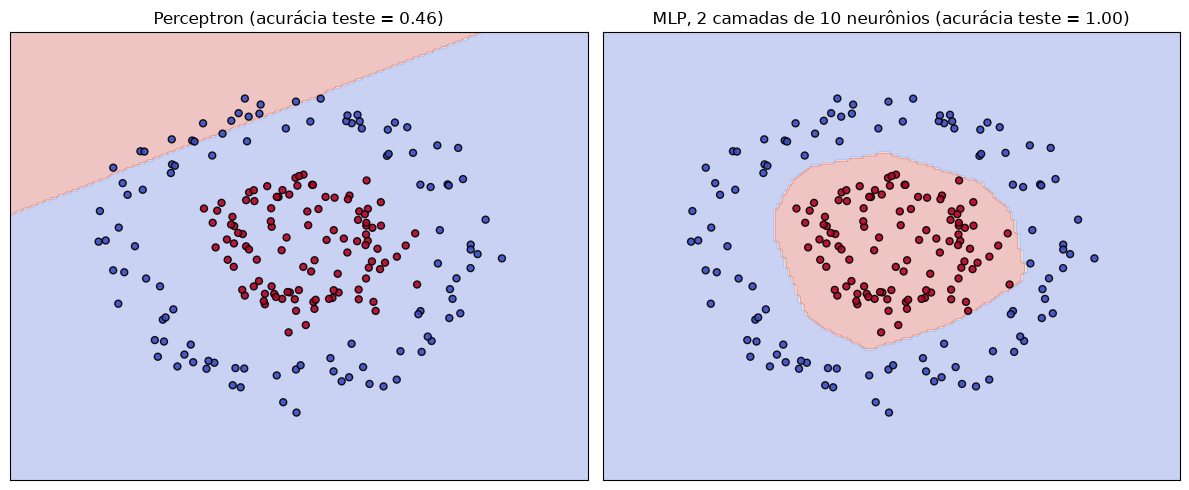

In [12]:
# Treinamento de uma rede neural MLP (Multi-Layer Perceptron) com 2 camadas ocultas de 10 neurônios cada
mlp_circ = MLPClassifier(hidden_layer_sizes=(10,10), # duas camadas ocultas com 10 neurônios cada
                         activation='relu', # função de ativação ReLU (Rectified Linear Unit)
                         max_iter=2000,  # número máximo de iterações (épocas) sobre os dados de treinamento
                         random_state=42)

mlp_circ.fit(X_circ_train, y_circ_train) # Treina a rede neural

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_regions(perc_circ, X_circ_train, y_circ_train, axes[0], f'Perceptron (acurácia teste = {acc_circ_perc:.2f})')

acc_circ_mlp = accuracy_score(y_circ_test, mlp_circ.predict(X_circ_test))
plot_decision_regions(mlp_circ, X_circ_train, y_circ_train, axes[1], f'MLP, 2 camadas de 10 neurônios (acurácia teste = {acc_circ_mlp:.2f})')

plt.tight_layout()
plt.show()

Vemos que com apenas duas camadas ocultas de 10 neurônios cada, o MLP consegue desenhar uma fronteira de decisão que acompanha corretamente o formato circular dos dados, o que é algo estruturalmente impossível para o Perceptron.

### Classificação da base Iris com o MLP

Voltando à base da flor íris (agora com 3 classes e 4 atributos), vamos comparar o Perceptron simples com o MLP.

In [14]:
# Lê um aquivo CSV e separa os atributos (todas as colunas, exceto a última) da variável alvo (última coluna). 
# Remove colunas de identificador ('Id'/'id'), que não são atributos preditivos.
caminho = r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv"

dados = pd.read_csv(caminho, header=0)
for col_id in ("Id", "id", "ID"):
    if col_id in dados.columns:
        dados = dados.drop(columns=[col_id])
y = dados.iloc[:, -1].to_numpy()
X = dados.iloc[:, :-1].to_numpy().astype(float)

p = 0.7  # fração de elementos no conjunto de treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=p, random_state=42, stratify=y)

print('Treinamento:', X_train.shape, ' Teste:', X_test.shape)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Treinamento: (105, 4)  Teste: (45, 4)


In [15]:
mlp_iris = MLPClassifier(
    solver='adam',
    alpha=1e-5,                 # regularização L2 (pequena)
    hidden_layer_sizes=(10, 10),  # duas camadas ocultas de 10 neurônios
    max_iter=1000,
    random_state=1,
)
mlp_iris.fit(X_train, y_train)

y_pred = mlp_iris.predict(X_test)
print('Acurácia do MLP no Iris:', accuracy_score(y_test, y_pred))
print('Acurácia do Perceptron no Iris (calculada antes):', accuracy_score(y_test, y_pred))

Acurácia do MLP no Iris: 0.9333333333333333
Acurácia do Perceptron no Iris (calculada antes): 0.9333333333333333


Na base da flor íris, o MLP obteve uma acurácia um pouco maior que o Perceptron simples. Isso é esperado: apesar de as três espécies serem quase linearmente separáveis (como já vimos na aula sobre regressão logística), há alguma sobreposição real entre *versicolor* e *virginica*. A fronteira ligeiramente mais flexível do MLP consegue lidar um pouco melhor com essa região de sobreposição do que a fronteira estritamente linear do Perceptron. Ainda assim, a diferença aqui é bem mais modesta do que a que vimos no exemplo dos círculos. A vantagem do MLP se torna dramática justamente quando a relação entre atributos e classes é genuinamente não linear, e não apenas quando há um pouco de sobreposição entre classes majoritariamente separáveis.

O scikit-learn guarda, automaticamente, o histórico da função de custo durante o treinamento do MLP, no atributo `.loss_curve_`, que é muito útil para verificar se o treinamento convergiu (se a curva estabilizou) ou se precisaríamos de mais iterações (`max_iter`).

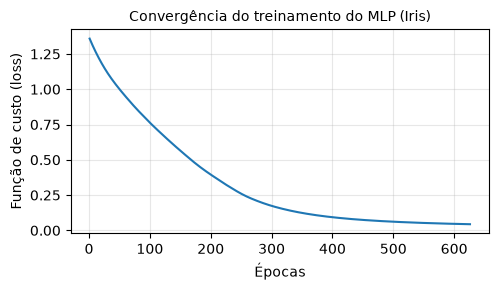

In [16]:
plt.figure(figsize=(5, 3))
epocas = range(1, len(mlp_iris.loss_curve_) + 1) # Cria uma sequência de épocas
plt.plot(epocas, mlp_iris.loss_curve_)
plt.xlabel('Épocas')
plt.ylabel('Função de custo (loss)')
plt.title('Convergência do treinamento do MLP (Iris)', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Classificação dos dados de veículos

Vamos aplicar o MLP a um problema mais desafiador: classificar silhuetas de veículos em 4 categorias (ônibus, van, e dois modelos de carro) a partir de 18 atributos geométricos extraídos de imagens.

In [17]:
caminho = r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\Vehicle.csv"

dados = pd.read_csv(caminho, header=0)

for col_id in ("Id", "id", "ID"):
    if col_id in dados.columns:
        dados = dados.drop(columns=[col_id])
y = dados.iloc[:, -1].to_numpy()
X = dados.iloc[:, :-1].to_numpy().astype(float)

print('Número de observações e atributos:', X.shape)
print('Classes:', np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Número de observações e atributos: (846, 18)
Classes: ['bus' 'opel' 'saab' 'van']


### Ajuste de hiperparâmetros

Em vez de escolher a arquitetura da rede (número de camadas e neurônios) e os demais hiperparâmetros sem um critério, vamos usar validação cruzada para buscar sistematicamente uma boa combinação.

In [18]:
# Define o espaço de busca dos hiperparâmetros da rede neural.
# O GridSearchCV testará todas as combinações possíveis desses valores.
parameter_space = {    
    # Define a arquitetura das camadas ocultas.
    # Cada tupla representa o número de neurônios em cada camada:
    # (50,)     -> uma camada oculta com 50 neurônios
    # (100, 50) -> duas camadas ocultas, com 100 e 50 neurônios
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 50,10)],
    
    # Define a função de ativação utilizada nas camadas ocultas.
    # tanh: função tangente hiperbólica
    # relu: função linear retificada
    'activation': ['tanh', 'relu'],
    
    # Define o parâmetro de regularização L2.
    # Valores maiores penalizam mais fortemente pesos elevados, ajudando a reduzir o sobreajuste.
    'alpha': [1e-4, 1e-3, 1e-2],
}

# Cria o classificador baseado em uma rede neural MLP.
# max_iter=1000 permite até 1000 épocas/iterações de treinamento.
mlp = MLPClassifier(max_iter=2000,
                    random_state=42)

# Configura a busca em grade dos melhores hiperparâmetros.
# mlp: modelo que será ajustado.
# parameter_space: combinações de hiperparâmetros que serão testadas.
# n_jobs=-1: utiliza todos os núcleos disponíveis do processador.
# cv=5: utiliza validação cruzada com cinco partições.
# Como não foi especificada a métrica em scoring, será utilizada a métrica padrão do MLPClassifier, que é a acurácia.
grid = GridSearchCV(estimator=mlp,
                    param_grid=parameter_space,
                    n_jobs=-1,cv=5)

# Executa a busca dos hiperparâmetros utilizando apenas os dados de treinamento previamente padronizados.
# Para cada combinação de hiperparâmetros, o conjunto de treinamento é dividido em cinco partes. 
# O modelo é treinado em quatro partes e validado na parte restante. Esse processo é repetido cinco vezes.
grid.fit(X_train, y_train)

# Mostra a combinação de hiperparâmetros que apresentou a maior acurácia média durante a validação cruzada.
print('Melhores hiperparâmetros:', grid.best_params_)

# Mostra a acurácia média de validação cruzada obtida pela melhor combinação de hiperparâmetros.
print('Melhor acurácia média (validação cruzada):',grid.best_score_)

Melhores hiperparâmetros: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50, 10)}
Melhor acurácia média (validação cruzada): 0.8638997821350763


Acurácia no conjunto de teste: 0.8470588235294118

              precision    recall  f1-score   support

         bus       0.98      1.00      0.99        44
        opel       0.76      0.60      0.67        42
        saab       0.69      0.82      0.75        44
         van       0.97      0.97      0.97        40

    accuracy                           0.85       170
   macro avg       0.85      0.85      0.85       170
weighted avg       0.85      0.85      0.84       170



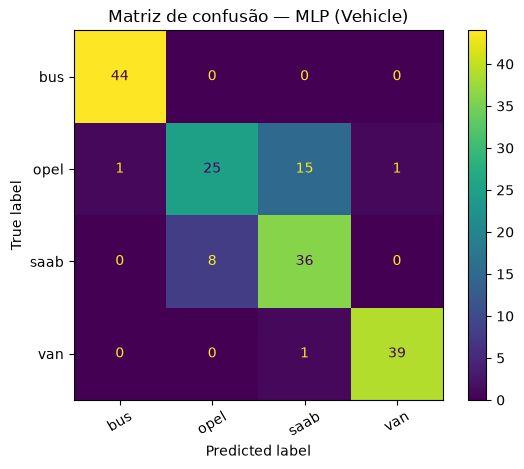

In [19]:
# Recupera o melhor modelo encontrado pelo GridSearchCV.
# Esse estimador já foi ajustado novamente usando todo o conjunto de treinamento com a melhor combinação de hiperparâmetros.
best_mlp = grid.best_estimator_

# Utiliza o melhor modelo para prever as classes do conjunto de teste.
y_pred = best_mlp.predict(X_test)

# Calcula a acurácia no conjunto de teste.
# A acurácia corresponde à proporção total de exemplos classificados corretamente.
print('Acurácia no conjunto de teste:',accuracy_score(y_test, y_pred))
print()
# Exibe métricas separadas para cada classe:
print(classification_report(y_test, y_pred))

# Constrói a matriz de confusão a partir das classes reais e das classes previstas pelo modelo.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=30
)
plt.title('Matriz de confusão — MLP (Vehicle)')
plt.show()

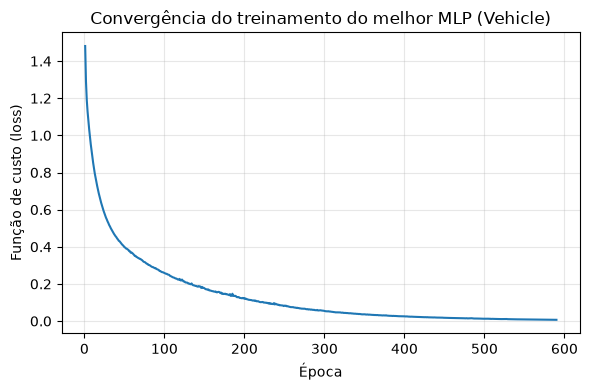

In [20]:
# Cria explicitamente o eixo das épocas.
# Cada valor de loss_curve_ corresponde ao final de uma época de treinamento.
epocas = range(1, len(best_mlp.loss_curve_) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epocas, best_mlp.loss_curve_)

plt.xlabel('Época')
plt.ylabel('Função de custo (loss)')
plt.title('Convergência do treinamento do melhor MLP (Vehicle)')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Regressão com o MLP

O `MLPRegressor` aplica exatamente a mesma arquitetura (camadas de neurônios com ativação não linear nas camadas ocultas), mas a camada de saída tem um único neurônio, **sem** função de ativação, produzindo diretamente um valor numérico contínuo, em vez de uma probabilidade de classe. Vamos prever o valor da resistência à compressão do concreto no conjunto **Concrete Compressive Strength Dataset**.

In [21]:
caminho = r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\concrete_data.csv"

df = pd.read_csv(caminho, header=0)
print('Número de observações e atributos:', df.shape)
df.head()

Número de observações e atributos: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [25]:
X = df.drop('concrete_compressive_strength', axis=1).to_numpy()
y = df['concrete_compressive_strength'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

# Treinamento de uma rede neural MLP (Multi-Layer Perceptron) para regressão com 2 camadas ocultas de 100 e 50 neurônios
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42,
)
mlp_reg.fit(X_train_std, y_train) # Treina o modelo

y_pred = mlp_reg.predict(X_test_std) # Faz a predição no conjunto de teste

# Calcula métricas de avaliação do modelo de regressão
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 5.644
R²: 0.876


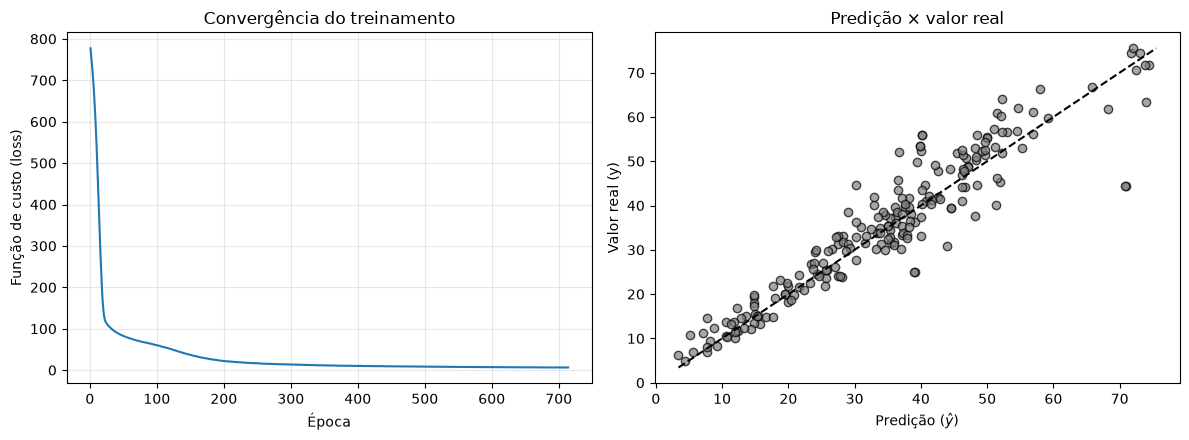

In [26]:
# Cada posição de loss_curve_ contém a perda ao final de uma época.
epocas = range(1, len(mlp_reg.loss_curve_) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epocas, mlp_reg.loss_curve_)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Função de custo (loss)')
axes[0].set_title('Convergência do treinamento')
axes[0].grid(alpha=0.3)

axes[1].scatter(y_pred, y_test, alpha=0.7, edgecolor='k', color='gray')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, 'k--')
axes[1].set_xlabel(r'Predição ($\hat{y}$)')
axes[1].set_ylabel('Valor real (y)')
axes[1].set_title('Predição × valor real')

plt.tight_layout()
plt.show()

## Seleção e ajuste do modelo

Vamos realizar a seleção dos hiperparâmetros usando `GridSearchCV`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn import metrics

Leitura dos dados.

In [29]:
caminho = r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\concrete_data.csv"

df = pd.read_csv(caminho, header=0)

print('Número de observações e atributos:', df.shape)
display(df.head())

# Matriz de atributos
# atributo alvo está na última coluna
target = df.columns[-1]
X = df.drop(target,axis=1).to_numpy()

# Variável resposta
y = df[target].to_numpy()

Número de observações e atributos: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


Separação entre treinamento e teste.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print('Tamanho do conjunto de treinamento:', X_train.shape)
print('Tamanho do conjunto de teste:', X_test.shape)

Tamanho do conjunto de treinamento: (824, 8)
Tamanho do conjunto de teste: (206, 8)


Podemos usar um pipeline, de modo que o StandardScaler é ajustado separadamente em cada divisão da validação cruzada, evitando vazamento de informação.

In [31]:
# abaixo estão comentadas algumas opções dos hiperparâmetros, pois o processamento pode ser muito lento.
# tente rodar o código com as opções descomentadas
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        max_iter=2000,
        random_state=42
    ))
])

parameter_space = {
    'mlp__hidden_layer_sizes': [
        (50,),
        (100,),
        (50, 50),
        #(100, 50),
        #(100, 100)
    ],

    'mlp__activation': [
        'tanh',
        'relu'
    ],

    'mlp__alpha': [
        #1e-5,
        #1e-4,
        1e-3,
        1e-2
    ],

    'mlp__learning_rate_init': [
        1e-4,
        1e-3,
        1e-2
    ]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_space,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__activation': ['tanh', 'relu'], 'mlp__alpha': [0.001, 0.01], 'mlp__hidden_layer_sizes': [(50,), (100,), ...], 'mlp__learning_rate_init': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know m

Resultados da validação cruzada.

In [34]:
print('Melhores hiperparâmetros:')
print(grid.best_params_)

melhor_rmse_cv = -grid.best_score_ # O GridSearchCV retorna o score negativo do RMSE, então precisamos inverter o sinal para obter o valor positivo do RMSE. 

print(
    f'Melhor RMSE médio na validação cruzada: '
    f'{melhor_rmse_cv:.3f}'
)

Melhores hiperparâmetros:
{'mlp__activation': 'tanh', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (50, 50), 'mlp__learning_rate_init': 0.001}
Melhor RMSE médio na validação cruzada: 5.130


Avaliação no conjunto de teste.

In [35]:
# Recupera o melhor modelo encontrado pelo GridSearchCV.
best_mlp = grid.best_estimator_

# Faz a predição no conjunto de teste usando o melhor modelo encontrado.
y_pred = best_mlp.predict(X_test)

# Calcula métricas de avaliação do modelo de regressão
mse = metrics.mean_squared_error(
    y_test,
    y_pred
)

# Calcula o RMSE a partir do MSE
rmse = np.sqrt(mse)

# Calcula o MAE (Mean Absolute Error)
mae = metrics.mean_absolute_error(
    y_test,
    y_pred
)

# Calcula o R² (coeficiente de determinação)
r2 = metrics.r2_score(
    y_test,
    y_pred
)

print('\nDesempenho no conjunto de teste:')
print(f'MAE:  {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²:   {r2:.3f}')


Desempenho no conjunto de teste:
MAE:  3.722
RMSE: 5.361
R²:   0.888


Curva de convergência e valores previstos.

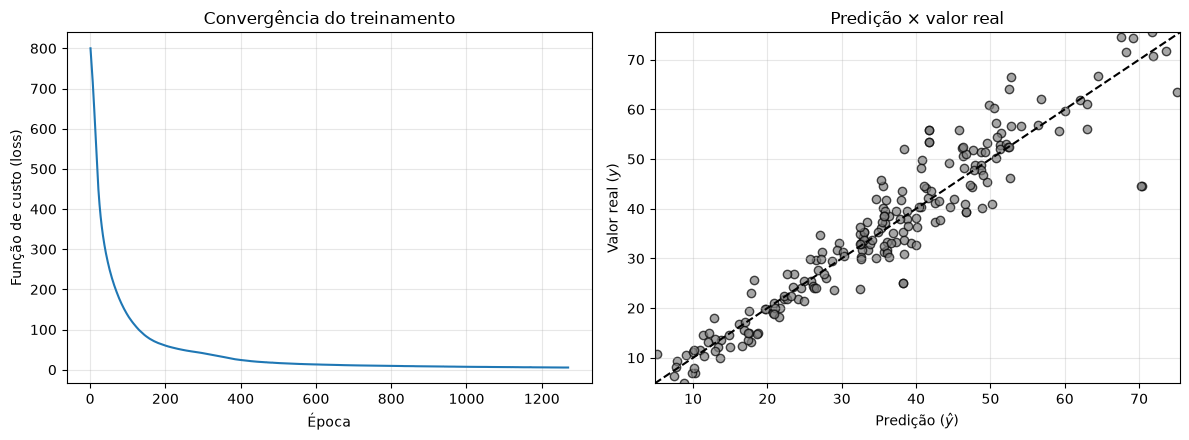

In [36]:
# Recupera apenas o MLPRegressor armazenado na etapa chamada 'mlp' dentro do melhor pipeline encontrado pelo GridSearchCV.
# O objeto best_mlp contém duas etapas:
# 1. padronização dos atributos;
# 2. treinamento da rede neural.
# O atributo named_steps permite acessar cada uma dessas etapas pelo nome definido no Pipeline.
mlp_reg = best_mlp.named_steps['mlp']

# Cria o eixo horizontal correspondente às épocas.
# O atributo loss_curve_ contém o valor da função de perda registrado ao final de cada época de treinamento.
# Como os índices das listas em Python começam em zero, utiliza-se range(1, ... + 1) para que o gráfico comece na época 1.
epocas = range(1,len(mlp_reg.loss_curve_) + 1)

# Cria uma figura com dois gráficos posicionados lado a lado.
fig, axes = plt.subplots(1,2,figsize=(12, 4.5))

# Curva de convergência do treinamento
# Plota o valor da função de perda em cada época.
# Uma redução da perda ao longo das épocas indica que o algoritmo está ajustando os pesos da rede e diminuindo o erro sobre os dados de treinamento.
axes[0].plot(epocas,mlp_reg.loss_curve_)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Função de custo (loss)')
axes[0].set_title('Convergência do treinamento')
axes[0].grid(alpha=0.3)


# Valores previstos versus valores reais
# eixo horizontal: valores previstos pelo modelo;
# eixo vertical: valores reais do conjunto de teste.
# Quanto mais próximos os pontos estiverem da diagonal, melhores serão as previsões.
axes[1].scatter(y_pred,y_test,alpha=0.7,edgecolor='k',color='gray')
# Determina os limites mínimo e máximo comuns aos dois eixos.
lims = [min(y_test.min(), y_pred.min()),max(y_test.max(), y_pred.max())]
# Desenha a linha de referência y = x.
axes[1].plot(lims,lims,'k--')
# Aplica os mesmos limites aos dois eixos.
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_xlabel(r'Predição ($\hat{y}$)')
axes[1].set_ylabel(r'Valor real ($y$)')
axes[1].set_title('Predição × valor real')
axes[1].grid(alpha=0.3)

# Ajusta automaticamente os espaçamentos entre os gráficos, evitando sobreposição de títulos e rótulos.
plt.tight_layout()
plt.show()

A curva de perda mostra se o treinamento convergiu, enquanto o gráfico de dispersão mostra a qualidade das previsões no conjunto de teste. Mesmo que a perda diminua adequadamente, o segundo gráfico ainda pode revelar erros sistemáticos, dispersão elevada ou dificuldade do modelo em prever valores extremos.

## Exercícios de fixação

1 - Repita a comparação entre Perceptron e MLP feita para os dados circulares (`make_circles`), mas usando `make_moons` no lugar. Além disso, varie o número de camadas ocultas do MLP (por exemplo, `(5,)`, `(10, 10)` e `(50, 50, 50)`) e observe como a fronteira de decisão muda. Redes maiores sempre produzem uma fronteira melhor nesses dados? Existe algum sinal de overfitting (fronteira muito irregular, ajustando-se a pontos isolados) nas redes maiores?

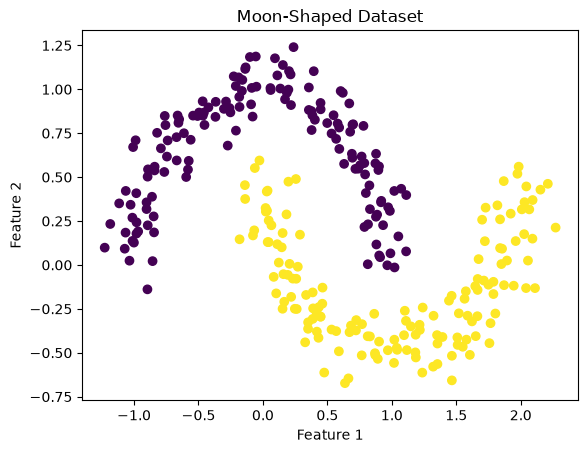

--------------------------------------------------------------------------------
Tamanho do conjunto de treinamento: (210, 2)
Tamanho do conjunto de teste: (90, 2)
--------------------------------------------------------------------------------


In [49]:
from sklearn.datasets import make_moons
import numpy as np

def plot_decision_regions(model, X, y, ax, title):
    """Desenha a região de decisão de um classificador binário já
    treinado, sobre um grid 2D, junto com os pontos de treinamento.
    """
    # Define o tamanho do passo (resolução) da malha do gráfico
    h = 0.02

    # Encontra os limites mínimos e máximos das duas features (eixos X e Y)
    # Adiciona uma folga de 0.5 para os pontos não ficarem colados nas bordas
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Cria a malha de pontos (grid) combinando os arrays de X e Y
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Transforma o grid 2D em uma lista de pontos (coordenadas x, y),
    # passa para o modelo fazer a predição de classe para cada ponto...
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    # ... e redimensiona o resultado de volta para o formato original do grid
    Z = Z.reshape(xx.shape)

    # Preenche o fundo do gráfico com as cores das predições (fronteira de decisão)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

    # Plota os pontos reais do dataset (as amostras de treino/teste)
    ax.scatter(X[:, 0],X[:, 1],c=y,cmap="coolwarm",s=25,edgecolor="k",alpha=0.9,)
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())
    
X_moon, y_moon = make_moons(n_samples=300, noise=0.1, random_state=42)

# Visualize the dataset
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Moon-Shaped Dataset')
plt.show()

# Divide o conjunto de dados em treinamento e teste, mantendo a proporção das classes (stratify=y_moon)
X_moon_train, X_moon_test, y_moon_train, y_moon_test = train_test_split(
    X_moon, y_moon, test_size=0.3, random_state=42, stratify=y_moon)

# Imprime os tamanhos dos conjuntos de treinamento e teste    
print("-" * 80)
print('Tamanho do conjunto de treinamento:', X_moon_train.shape)
print('Tamanho do conjunto de teste:', X_moon_test.shape)
print("-" * 80)

In [ ]:
# Treina o Perceptron e MLPs com diferentes arquiteturas no conjunto de treinamento
perc_moon = Perceptron(max_iter=1000, random_state=8)
perc_moon.fit(X_moon_train, y_moon_train)
acc_moon_perc = accuracy_score(y_moon_test, perc_moon.predict(X_moon_test))

# Arquiteturas do MLP pedidas no enunciado
arquiteturas = [(5,), (10, 10), (50, 50, 50)]
mlps_moon = {} # Dicionário para armazenar os modelos MLP treinados com diferentes arquiteturas

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

plot_decision_regions(perc_moon, X_moon_train, y_moon_train, axes[0], f'Perceptron (acurácia teste = {acc_moon_perc:.2f})')

for ax, arch in zip(axes[1:], arquiteturas):
    mlp = MLPClassifier(hidden_layer_sizes=arch,
                         activation='relu',
                         max_iter=2000,
                         random_state=42)
    mlp.fit(X_moon_train, y_moon_train)
    mlps_moon[arch] = mlp

    acc_train = accuracy_score(y_moon_train, mlp.predict(X_moon_train))
    acc_test = accuracy_score(y_moon_test, mlp.predict(X_moon_test))

    plot_decision_regions(mlp, X_moon_train, y_moon_train, ax,
                           f'MLP {arch}\n(treino = {acc_train:.2f}, teste = {acc_test:.2f})')

plt.tight_layout()
plt.show()

# Comparação numérica: o gap entre acurácia de treino e teste é o sinal
# mais confiável de overfitting (mais confiável do que "olhar a fronteira").
print(f"{'Arquitetura':<18}{'Acc. treino':>15}{'Acc. teste':>15}")
for arch, mlp in mlps_moon.items():
    acc_train = accuracy_score(y_moon_train, mlp.predict(X_moon_train))
    acc_test = accuracy_score(y_moon_test, mlp.predict(X_moon_test))
    print(f"{str(arch):<18}{acc_train:>15.3f}{acc_test:>15.3f}")

 Resposta

| Modelo | Acc. treino | Acc. teste |
|---|---|---|
| Perceptron | — | 0.80 |
| MLP `(5,)` | 0.87 | 0.86 |
| MLP `(10, 10)` | 0.95 | 0.92 |
| MLP `(50, 50, 50)` | 1.00 | 1.00 |

- **Perceptron**: como só consegue traçar uma fronteira linear (uma reta), não acompanha o formato de "meia-lua" dos dados e erra bastante justamente na região onde as duas luas se entrelaçam.
- **MLP `(5,)`**: já consegue curvar a fronteira, mas com poucos neurônios a curva ainda fica "grosseira" perto da região de sobreposição entre as classes.
- **MLP `(10, 10)`**: a fronteira acompanha bem melhor o formato das luas.
- **MLP `(50, 50, 50)`**: a fronteira se ajusta muito bem ao formato dos dados, acertando 100% tanto no treino quanto no teste.

Redes maiores **não** produzem sempre uma fronteira melhor — depende dos dados. Aqui elas ajudam porque o problema é de baixa dimensão (2D), a base é relativamente "limpa" (`noise=0.1`, sem outliers extremos) e há dados de treino suficientes (210 pontos) para o número de parâmetros da rede. Em bases mais ruidosas, com menos exemplos ou mais atributos, aumentar demais a rede tende a piorar a generalização.

Quanto a overfitting: o sinal mais confiável não é "olhar a fronteira e achar irregular", e sim comparar a acurácia de treino com a de teste. Na rede `(50, 50, 50)` as duas acurácias são iguais (1.00), então **não há indício de overfitting** apesar de ser o modelo mais flexível testado: ela generalizou bem, não apenas decorou o conjunto de treino. Visualmente, a fronteira dela também continua suave e acompanha o formato das luas, sem "dobras" isoladas ao redor de pontos individuais (o que seria o sinal visual de overfitting).


2 - Na classificação do Vehicle, adicione `'solver'` e `'learning_rate'` à grade de hiperparâmetros do `GridSearchCV` (por exemplo, `'solver': ['adam', 'sgd']` e `'learning_rate': ['constant', 'adaptive']`, este último relevante apenas quando `solver='sgd'`). Os melhores hiperparâmetros mudam? A acurácia no conjunto de teste melhora?

In [ ]:
# As variáveis X_train/X_test/grid/best_mlp da seção do Vehicle foram sobrescritas
# mais adiante no notebook (pela seção de regressão com dados de concreto).
# Por isso, recarregamos e repreparamos os dados do Vehicle aqui, exatamente como antes.
caminho = r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\Vehicle.csv"

dados = pd.read_csv(caminho, header=0)
for col_id in ("Id", "id", "ID"):
    if col_id in dados.columns:
        dados = dados.drop(columns=[col_id])
y_v = dados.iloc[:, -1].to_numpy()
X_v = dados.iloc[:, :-1].to_numpy().astype(float)

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_v, y_v, test_size=0.2, random_state=42, stratify=y_v)

scaler_v = StandardScaler().fit(X_train_v)
X_train_v = scaler_v.transform(X_train_v)
X_test_v = scaler_v.transform(X_test_v)

# Grade original (igual à usada antes), como referência de comparação
parameter_space_base = {
    'hidden_layer_sizes': [(50,), # uma camada oculta com 50 neurônios
                           (100,), # uma camada oculta com 100 neurônios
                           (50, 50), # duas camadas ocultas com 50 neurônios cada
                           (100, 50), # uma camada oculta com 100 neurônios e outra com 50
                           (100, 50, 10)], # três camadas ocultas com 100, 50 e 10 neurônios respectivamente
    'activation': ['tanh', 'relu'],
    'alpha': [1e-4, 1e-3, 1e-2],
}
grid_base = GridSearchCV(
    estimator=MLPClassifier(max_iter=2000, 
                            random_state=42),
    param_grid=parameter_space_base,
    n_jobs=-1, cv=5,
)
grid_base.fit(X_train_v, y_train_v)
acc_teste_base = accuracy_score(y_test_v, grid_base.best_estimator_.predict(X_test_v))

# Grade ampliada, incluindo 'solver' e 'learning_rate'
# ('learning_rate' só tem efeito quando solver='sgd'; é ignorado quando solver='adam')
parameter_space_ext = {
    'hidden_layer_sizes': [(50,), # uma camada oculta com 50 neurônios
                           (100,), # uma camada oculta com 100 neurônios
                           (50, 50), # duas camadas ocultas com 50 neurônios cada
                           (100, 50), # uma camada oculta com 100 neurônios e outra com 50
                           (100, 50, 10)], # três camadas ocultas com 100, 50 e 10 neurônios respectivamente
    'activation': ['tanh', 'relu'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'solver': ['adam', 'sgd'], # solver 'adam' é um método de otimização baseado em gradiente estocástico adaptativo; 'sgd' é o gradiente estocástico padrão
    'learning_rate': ['constant', 'adaptive'], # define a taxa de aprendizado inicial e como ela muda durante o treinamento. 'constant' mantém a taxa de aprendizado constante; 'adaptive' reduz a taxa de aprendizado quando a função de perda não melhora por um certo número de épocas.
}
grid_ext = GridSearchCV(
    estimator=MLPClassifier(max_iter=2000, random_state=42),
    param_grid=parameter_space_ext,
    n_jobs=-1, cv=5,
)
grid_ext.fit(X_train_v, y_train_v)
acc_teste_ext = accuracy_score(y_test_v, grid_ext.best_estimator_.predict(X_test_v))

print('=== Grade original ===')
print('Melhores hiperparâmetros:', grid_base.best_params_)
print('Melhor acurácia média (CV):', grid_base.best_score_)
print('Acurácia no conjunto de teste:', acc_teste_base)
print()
print('=== Grade ampliada (com solver e learning_rate) ===')
print('Melhores hiperparâmetros:', grid_ext.best_params_)
print('Melhor acurácia média (CV):', grid_ext.best_score_)
print('Acurácia no conjunto de teste:', acc_teste_ext)

=== Grade original ===
Melhores hiperparâmetros: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50, 10)}
Melhor acurácia média (CV): 0.8638997821350763
Acurácia no conjunto de teste: 0.8470588235294118

=== Grade ampliada (com solver e learning_rate) ===
Melhores hiperparâmetros: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50, 10), 'learning_rate': 'constant', 'solver': 'adam'}
Melhor acurácia média (CV): 0.8638997821350763
Acurácia no conjunto de teste: 0.8470588235294118


 Resposta

| Grade | Melhores hiperparâmetros | Acc. média (CV) | Acc. teste |
|---|---|---|---|
| Original | `activation='tanh'`, `alpha=0.0001`, `hidden_layer_sizes=(100, 50, 10)` | 0.864 | 0.847 |
| Ampliada (+ solver, learning_rate) | `activation='tanh'`, `alpha=0.0001`, `hidden_layer_sizes=(100, 50, 10)`, `solver='adam'`, `learning_rate='constant'` | 0.864 | 0.847 |

Os melhores hiperparâmetros praticamente **não mudam**, e a acurácia no conjunto de teste **não melhora** (permanece 0.847).

Isso faz sentido porque `'adam'` já é o `solver` **padrão** do `MLPClassifier`. Ou seja, a grade original já estava implicitamente usando `solver='adam'` em todas as suas combinações — adicionar `'solver': ['adam', 'sgd']` apenas confirma que `'adam'` continua sendo melhor que `'sgd'` para esses dados, sem trazer nada de novo. E como o `GridSearchCV` escolheu `solver='adam'`, o hiperparâmetro `learning_rate` acaba sendo irrelevante na prática: ele só afeta o treinamento quando `solver='sgd'` (controla se a taxa de aprendizado do gradiente descendente estocástico é fixa ou diminui adaptativamente); com `solver='adam'` (que já ajusta a taxa de aprendizado internamente, de forma adaptativa, por conta própria), o valor de `learning_rate` é simplesmente ignorado.

Ou seja: ampliar a grade custou bem mais tempo de computação (muito mais combinações testadas), mas não trouxe ganho de desempenho — os dados do Vehicle já estavam sendo bem servidos pelo otimizador Adam, e trocar para SGD (com qualquer configuração de `learning_rate`) não superou isso.